In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

df = pd.read_csv("C:/Data_Analyst_Journey/Luke Barousse/job_postings_flat.csv")

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
country = 'United States'
job = 'Data Analyst'

df_selected = df[(df['job_title_short']==job) & (df['job_country']==country)].copy()

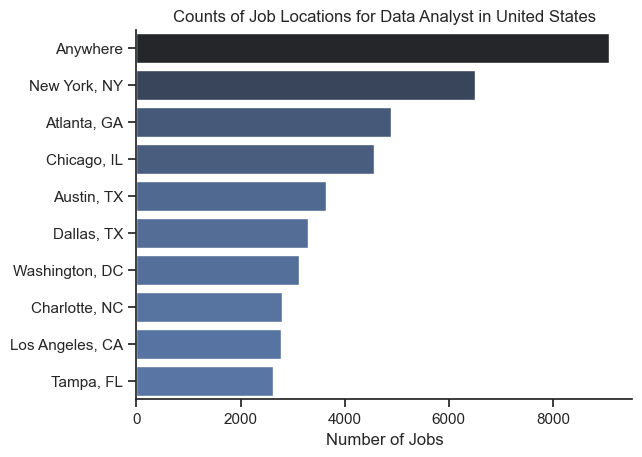

In [3]:
df_plot = df_selected['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title(f'Counts of Job Locations for {job} in {country}')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

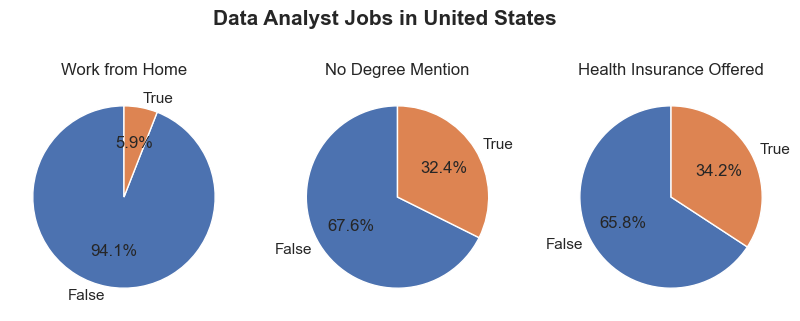

In [4]:
dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'No Degree Mention',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(10, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_selected[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

fig.suptitle(f'{job} Jobs in {country}', fontsize=15, fontweight='bold')
fig.subplots_adjust(top=1.1)
plt.show()

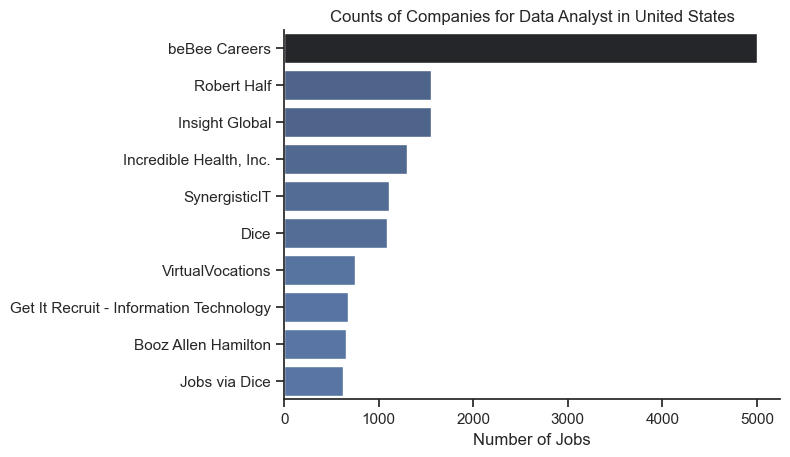

In [5]:
df_plot = df_selected['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title(f'Counts of Companies for {job} in {country}')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()